# Chronic Disease Prediction Pipeline
Full pipeline: preprocessing, statistical + ML-based feature selection (Chi-Square, RFE, PSO), baseline models, and a CNN adapted for tabular data, evaluated with a 70/30 train-test split and 5-fold cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import chi2, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_auc_score, f1_score, precision_score, recall_score)

import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1781633379.388163    3009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781633379.388813    3009 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781633379.438830    3009 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781633380.676483    3009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781633380.676896    3009 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Load Data

In [2]:
df = pd.read_csv("synthetic_chronic_diseases.csv")
print("Shape:", df.shape)
df.head()

Shape: (2000, 10)


,Age,Gender,BMI,Cholesterol,Blood_Pressure,Sugar_Level,Smoking,Physical_Activity,Hypertension,Chronic_Disease
0,68,Male,24.625522,205.731977,123.455429,97.010182,No,Moderate,No,0
1,58,Male,28.451317,242.160001,91.594247,72.636441,Yes,Low,Yes,1
2,44,Male,27.928578,228.549512,153.287981,132.324054,Yes,Moderate,Yes,1
3,72,Female,23.197961,197.868523,91.953009,136.781503,No,Moderate,Yes,0
4,37,Male,27.031132,220.487306,146.806927,101.234136,Yes,Moderate,No,1


In [3]:
print(df.info())
print(df.describe())
print("\nMissing values per column:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                2000 non-null   int64  
 1   Gender             2000 non-null   str    
 2   BMI                2000 non-null   float64
 3   Cholesterol        2000 non-null   float64
 4   Blood_Pressure     2000 non-null   float64
 5   Sugar_Level        2000 non-null   float64
 6   Smoking            2000 non-null   str    
 7   Physical_Activity  2000 non-null   str    
 8   Hypertension       2000 non-null   str    
 9   Chronic_Disease    2000 non-null   int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 156.4 KB
None
               Age          BMI  Cholesterol  Blood_Pressure  Sugar_Level  \
count  2000.000000  2000.000000  2000.000000     2000.000000  2000.000000   
mean     54.760000    29.385363   223.228380      135.754256   135.396213   
std      14.270046     6.178623 

## 2. Exploratory Data Analysis

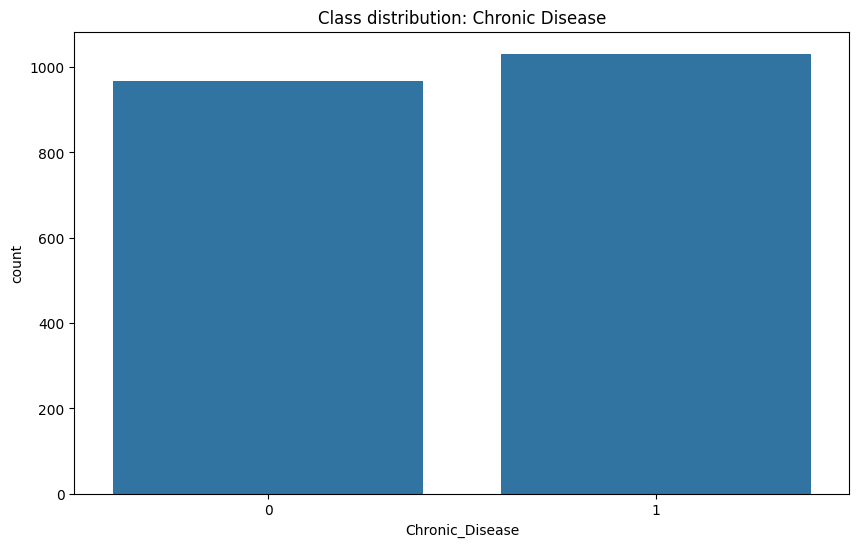

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Chronic_Disease", data=df)
plt.title("Class distribution: Chronic Disease")
plt.show()

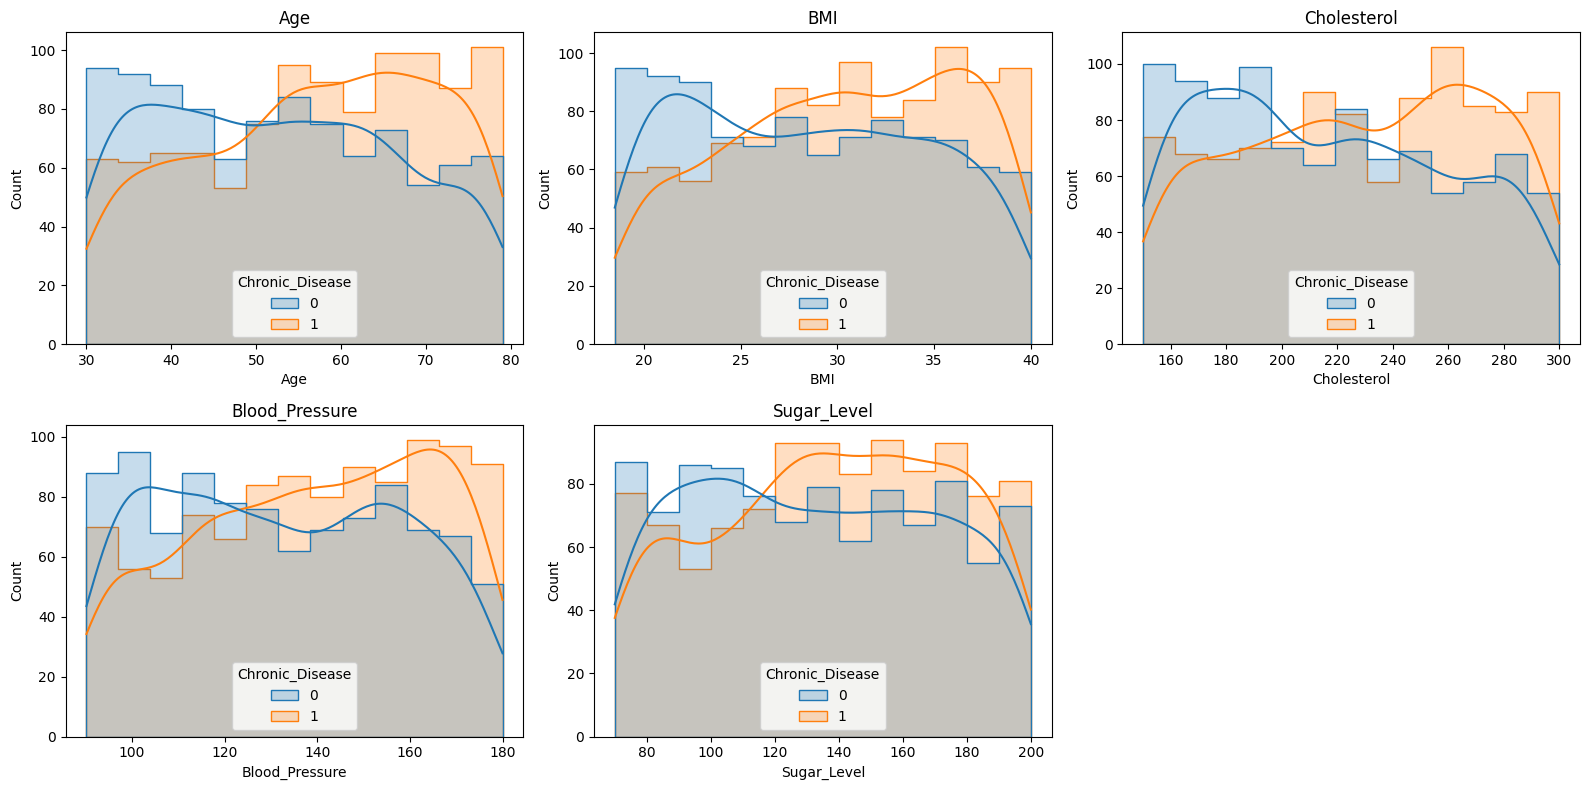

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num_cols = ["Age", "BMI", "Cholesterol", "Blood_Pressure", "Sugar_Level"]
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=df, x=col, hue="Chronic_Disease", kde=True, ax=ax, element="step")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

## 3. Data Preprocessing
- Missing numerical values imputed with the median, categorical with the mode.
- Duplicate rows removed.
- Outliers in numeric columns clipped using the IQR rule.
- Binary categoricals label-encoded; the 3-level `Physical_Activity` one-hot encoded.
- Numeric features standardized with Z-score scaling.

In [6]:
num_cols = ["Age", "BMI", "Cholesterol", "Blood_Pressure", "Sugar_Level"]
cat_cols = ["Gender", "Smoking", "Physical_Activity", "Hypertension"]
target_col = "Chronic_Disease"

# Imputation
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Outlier clipping via IQR
for c in num_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[c] = df[c].clip(lower, upper)

Removed 0 duplicate rows


In [7]:
# Encoding
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])          # Male/Female -> 0/1
le_smoke = LabelEncoder()
df["Smoking"] = le_smoke.fit_transform(df["Smoking"])         # Yes/No -> 1/0
le_htn = LabelEncoder()
df["Hypertension"] = le_htn.fit_transform(df["Hypertension"]) # Yes/No -> 1/0

df = pd.get_dummies(df, columns=["Physical_Activity"], drop_first=True)
dummy_cols = [c for c in df.columns if c.startswith("Physical_Activity_")]
df[dummy_cols] = df[dummy_cols].astype(int)

# Standardization
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,Age,Gender,BMI,Cholesterol,Blood_Pressure,Sugar_Level,Smoking,Hypertension,Chronic_Disease,Physical_Activity_Low,Physical_Activity_Moderate
0,0.928050,1,-0.770565,-0.401324,-0.475740,-1.029039,0,0,0,0,1
1,0.227106,1,-0.151212,0.434244,-1.708188,-1.682441,1,1,1,1,0
2,-0.754216,1,-0.235837,0.122054,0.678236,-0.082357,1,1,1,0,1
3,1.208427,0,-1.001671,-0.581692,-1.694310,0.037136,0,1,0,0,1
4,-1.244876,1,-0.381124,-0.062873,0.427537,-0.915805,1,0,1,0,1


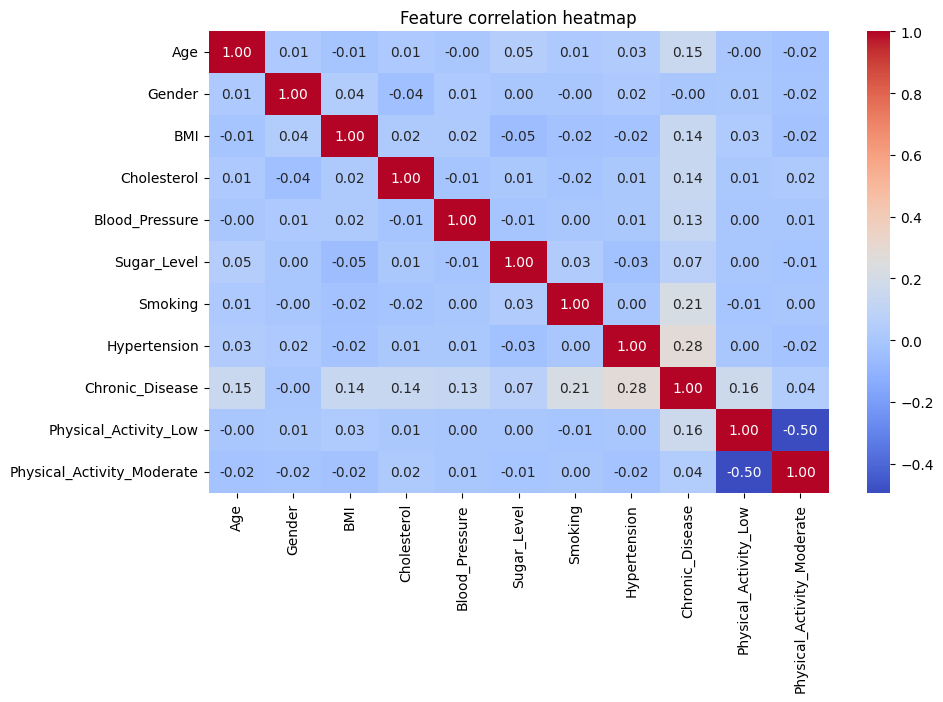

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature correlation heatmap")
plt.show()

In [9]:
X = df.drop(columns=[target_col])
y = df[target_col]
feature_names = X.columns.tolist()
print("Final feature columns:", feature_names)

Final feature columns: ['Age', 'Gender', 'BMI', 'Cholesterol', 'Blood_Pressure', 'Sugar_Level', 'Smoking', 'Hypertension', 'Physical_Activity_Low', 'Physical_Activity_Moderate']


## 4. Train/Test Split (70/30, Stratified)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train class balance:
 Chronic_Disease
1    0.515714
0    0.484286
Name: proportion, dtype: float64

Test class balance:
 Chronic_Disease
1    0.516667
0    0.483333
Name: proportion, dtype: float64


## 5. Feature Selection
Three complementary approaches are compared: a statistical test (Chi-Square), a model-based wrapper method (RFE), and a metaheuristic search (Particle Swarm Optimization).

### 5a. Chi-Square Test

Hypertension                  100.133681
Smoking                        47.306002
Physical_Activity_Low          33.355501
Age                            26.093806
Cholesterol                    22.046416
BMI                            22.032452
Blood_Pressure                 18.267826
Sugar_Level                     6.099987
Physical_Activity_Moderate      1.870147
Gender                          0.016102
dtype: float64


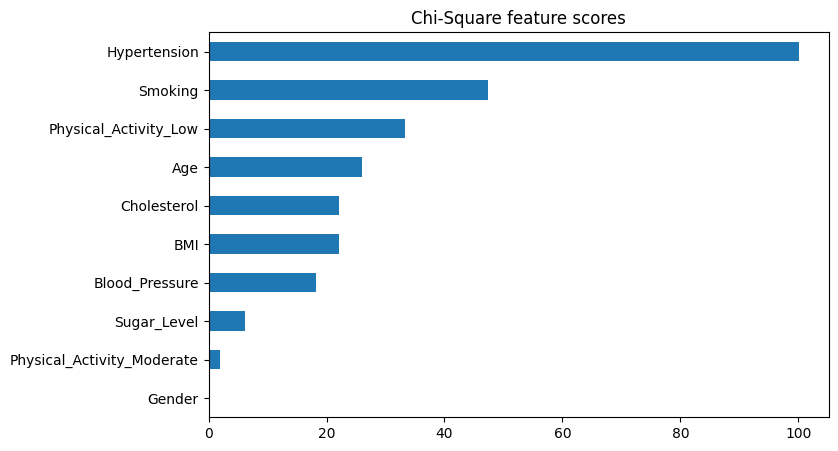

In [11]:
X_arr = X.to_numpy(dtype=float)
X_pos_arr = X_arr - X_arr.min(axis=0)  # chi2 requires non-negative inputs
chi_scores, chi_pvalues = chi2(X_pos_arr, y)
chi_results = pd.Series(chi_scores, index=feature_names).sort_values(ascending=False)
print(chi_results)

plt.figure(figsize=(8, 5))
chi_results.plot(kind="barh")
plt.title("Chi-Square feature scores")
plt.gca().invert_yaxis()
plt.show()

### 5b. Recursive Feature Elimination (RFE)

In [12]:
rfe_estimator = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=5)
rfe.fit(X_train, y_train)
rfe_selected = X_train.columns[rfe.support_].tolist()
print("RFE selected features:", rfe_selected)
print("\nFeature ranking (1 = selected):")
print(pd.Series(rfe.ranking_, index=feature_names).sort_values())

RFE selected features: ['Cholesterol', 'Smoking', 'Hypertension', 'Physical_Activity_Low', 'Physical_Activity_Moderate']

Feature ranking (1 = selected):
Cholesterol                   1
Hypertension                  1
Smoking                       1
Physical_Activity_Low         1
Physical_Activity_Moderate    1
Blood_Pressure                2
Age                           3
BMI                           4
Sugar_Level                   5
Gender                        6
dtype: int64


### 5c. Particle Swarm Optimization (PSO)
PSO searches over binary feature masks. Each particle is a vector of continuous values in [0, 1] (thresholded at 0.5 to decide inclusion); particles move through the search space influenced by their own best-known position and the swarm's global best, guided by inertia (`w`), cognitive (`c1`), and social (`c2`) coefficients. Fitness = 5-fold CV accuracy of a quick Random Forest on the selected subset, with a small penalty for using more features.

In [13]:
def fitness(mask, X_tr, y_tr):
    if mask.sum() == 0:
        return 0.0
    cols = X_tr.columns[mask.astype(bool)]
    clf = RandomForestClassifier(n_estimators=50, random_state=42)
    scores = cross_val_score(clf, X_tr[cols], y_tr, cv=5, scoring="accuracy")
    penalty = 0.001 * mask.sum()
    return scores.mean() - penalty


def pso_feature_selection(X_tr, y_tr, n_particles=10, n_iterations=15,
                           w=0.5, c1=1.0, c2=1.5, seed=42):
    rng = np.random.RandomState(seed)
    n_features = X_tr.shape[1]

    positions = rng.rand(n_particles, n_features)
    velocities = rng.uniform(-1, 1, (n_particles, n_features))

    def to_mask(pos):
        return (pos > 0.5).astype(int)

    pbest_pos = positions.copy()
    pbest_score = np.array([fitness(to_mask(p), X_tr, y_tr) for p in positions])

    gbest_idx = np.argmax(pbest_score)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_score = pbest_score[gbest_idx]
    history = [gbest_score]

    for it in range(n_iterations):
        for i in range(n_particles):
            r1, r2 = rng.rand(n_features), rng.rand(n_features)
            velocities[i] = (w * velocities[i]
                              + c1 * r1 * (pbest_pos[i] - positions[i])
                              + c2 * r2 * (gbest_pos - positions[i]))
            positions[i] = np.clip(positions[i] + velocities[i], 0, 1)

            mask = to_mask(positions[i])
            score = fitness(mask, X_tr, y_tr)
            if score > pbest_score[i]:
                pbest_score[i] = score
                pbest_pos[i] = positions[i].copy()

        best_i = np.argmax(pbest_score)
        if pbest_score[best_i] > gbest_score:
            gbest_score = pbest_score[best_i]
            gbest_pos = pbest_pos[best_i].copy()

        history.append(gbest_score)
        print(f"  iter {it+1}/{n_iterations} | best fitness so far: {gbest_score:.4f}")

    return to_mask(gbest_pos), gbest_score, history

Running PSO feature selection...


  iter 1/15 | best fitness so far: 0.6537


  iter 2/15 | best fitness so far: 0.6684


  iter 3/15 | best fitness so far: 0.6684


  iter 4/15 | best fitness so far: 0.6684


...

  iter 11/15 | best fitness so far: 0.6684


  iter 12/15 | best fitness so far: 0.6684


  iter 13/15 | best fitness so far: 0.6684


  iter 14/15 | best fitness so far: 0.6684


  iter 15/15 | best fitness so far: 0.6684

PSO selected features: ['Gender', 'BMI', 'Cholesterol', 'Blood_Pressure', 'Smoking', 'Hypertension', 'Physical_Activity_Low', 'Physical_Activity_Moderate']
PSO best fitness: 0.6684285714285714


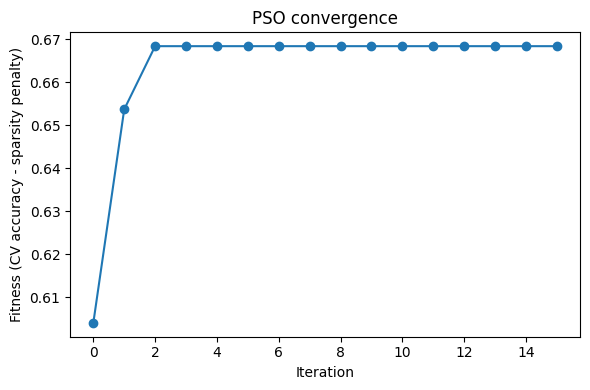

In [14]:
print("Running PSO feature selection...")
pso_mask, pso_score, pso_history = pso_feature_selection(X_train, y_train)
pso_selected = X_train.columns[pso_mask.astype(bool)].tolist()
print("\nPSO selected features:", pso_selected)
print("PSO best fitness:", pso_score)

plt.figure(figsize=(6, 4))
plt.plot(pso_history, marker="o")
plt.title("PSO convergence")
plt.xlabel("Iteration")
plt.ylabel("Fitness (CV accuracy - sparsity penalty)")
plt.tight_layout()
plt.show()

In [15]:
# Final feature set: PSO's selection, since it directly optimizes downstream
# classifier performance rather than a proxy statistic.
FINAL_FEATURES = pso_selected if len(pso_selected) >= 3 else rfe_selected
print("Final feature set used for modeling:", FINAL_FEATURES)

X_train_sel = X_train[FINAL_FEATURES]
X_test_sel = X_test[FINAL_FEATURES]

Final feature set used for modeling: ['Gender', 'BMI', 'Cholesterol', 'Blood_Pressure', 'Smoking', 'Hypertension', 'Physical_Activity_Low', 'Physical_Activity_Moderate']


## 6. Baseline Models
Logistic Regression, Decision Tree, Random Forest, and Naive Bayes, each evaluated with 5-fold cross-validation on the training set and a final check on the held-out test set.

In [16]:
baselines = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
}

baseline_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in baselines.items():
    cv_scores = cross_val_score(clf, X_train_sel, y_train, cv=skf, scoring="accuracy")
    clf.fit(X_train_sel, y_train)
    y_pred = clf.predict(X_test_sel)
    y_proba = clf.predict_proba(X_test_sel)[:, 1] if hasattr(clf, "predict_proba") else None

    baseline_results[name] = {
        "CV Accuracy (mean)": cv_scores.mean(),
        "CV Accuracy (std)": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
    }

baseline_df = pd.DataFrame(baseline_results).T
baseline_df

,CV Accuracy (mean),CV Accuracy (std),Test Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.695714,0.019483,0.708333,0.724252,0.703226,0.713584,0.785862
Decision Tree,0.602143,0.019509,0.590000,0.614286,0.554839,0.583051,0.591212
Random Forest,0.665714,0.014569,0.665000,0.692580,0.632258,0.661046,0.728003
Naive Bayes,0.672857,0.019898,0.713333,0.739583,0.687097,0.712375,0.772469


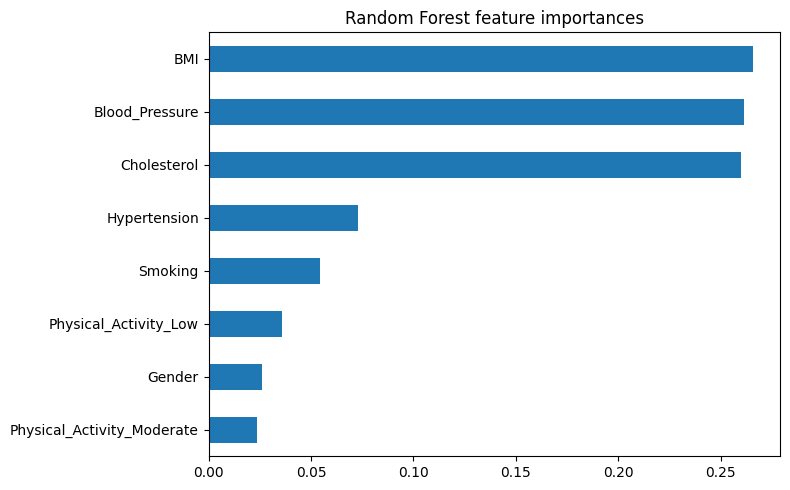

In [17]:
rf_clf = baselines["Random Forest"]
feature_importances = pd.Series(rf_clf.feature_importances_, index=FINAL_FEATURES)
feature_importances.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()

## 7. Convolutional Neural Network for Tabular Data
CNNs are normally used on images, where convolution exploits spatial locality between neighboring pixels. Here each patient's selected features are arranged as a 1D sequence and passed through `Conv1D` layers, letting the network learn local interactions between adjacent feature values before pooling them into a compact representation for classification.

In [18]:
n_features_final = len(FINAL_FEATURES)

X_train_cnn = X_train_sel.values.reshape(-1, n_features_final, 1).astype("float32")
X_test_cnn = X_test_sel.values.reshape(-1, n_features_final, 1).astype("float32")
y_train_arr = y_train.values.astype("float32")
y_test_arr = y_test.values.astype("float32")


def build_cnn(n_features):
    model = models.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.Conv1D(32, kernel_size=2, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2, padding="same"),
        layers.Conv1D(64, kernel_size=2, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

build_cnn(n_features_final).summary()

E0000 00:00:1781633455.740062    3009 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,753 (26.38 KB)

 Trainable params: 6,561 (25.63 KB)

 Non-trainable params: 192 (768.00 B)

### 7a. 5-Fold Cross-Validation

In [19]:
cnn_cv_accuracies = []
fold = 1
for train_idx, val_idx in skf.split(X_train_cnn, y_train_arr):
    model = build_cnn(n_features_final)
    model.fit(
        X_train_cnn[train_idx], y_train_arr[train_idx],
        validation_data=(X_train_cnn[val_idx], y_train_arr[val_idx]),
        epochs=30, batch_size=16, verbose=0,
    )
    val_loss, val_acc = model.evaluate(X_train_cnn[val_idx], y_train_arr[val_idx], verbose=0)
    cnn_cv_accuracies.append(val_acc)
    print(f"Fold {fold}/5 validation accuracy: {val_acc:.4f}")
    fold += 1

print(f"\nCNN 5-fold CV accuracy: {np.mean(cnn_cv_accuracies):.4f} +/- {np.std(cnn_cv_accuracies):.4f}")

Fold 1/5 validation accuracy: 0.6679


Fold 2/5 validation accuracy: 0.6464


Fold 3/5 validation accuracy: 0.6321


Fold 4/5 validation accuracy: 0.6607


Fold 5/5 validation accuracy: 0.6571

CNN 5-fold CV accuracy: 0.6529 +/- 0.0125


### 7b. Final CNN: Train on Full Training Set, Evaluate on Test Set

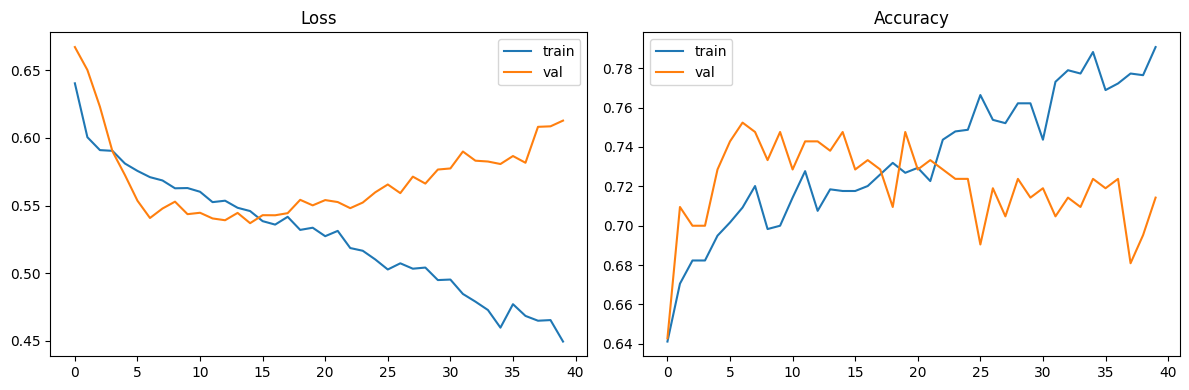

In [20]:
final_cnn = build_cnn(n_features_final)
history = final_cnn.fit(
    X_train_cnn, y_train_arr,
    validation_split=0.15,
    epochs=40, batch_size=16, verbose=0,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

--- CNN Test Set Performance ---
Accuracy:  0.6567
Precision: 0.7000
Recall:    0.5871
F1:        0.6386
AUC-ROC:   0.7087
              precision    recall  f1-score   support

         0.0       0.62      0.73      0.67       290
         1.0       0.70      0.59      0.64       310

    accuracy                           0.66       600
   macro avg       0.66      0.66      0.66       600
weighted avg       0.66      0.66      0.66       600



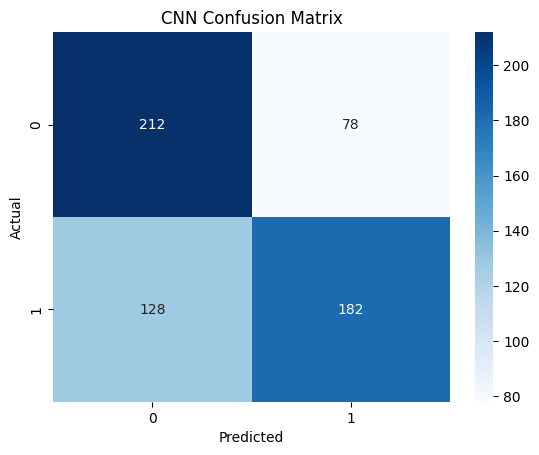

In [21]:
y_proba_cnn = final_cnn.predict(X_test_cnn, verbose=0).ravel()
y_pred_cnn = (y_proba_cnn > 0.5).astype(int)

cnn_acc = accuracy_score(y_test_arr, y_pred_cnn)
cnn_f1 = f1_score(y_test_arr, y_pred_cnn)
cnn_prec = precision_score(y_test_arr, y_pred_cnn)
cnn_rec = recall_score(y_test_arr, y_pred_cnn)
cnn_auc = roc_auc_score(y_test_arr, y_proba_cnn)

print("--- CNN Test Set Performance ---")
print(f"Accuracy:  {cnn_acc:.4f}")
print(f"Precision: {cnn_prec:.4f}")
print(f"Recall:    {cnn_rec:.4f}")
print(f"F1:        {cnn_f1:.4f}")
print(f"AUC-ROC:   {cnn_auc:.4f}")
print(classification_report(y_test_arr, y_pred_cnn))

cm = confusion_matrix(y_test_arr, y_pred_cnn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

## 8. Final Model Comparison

In [22]:
summary = baseline_df[["Test Accuracy", "Precision", "Recall", "F1", "AUC"]].copy()
summary.loc["CNN"] = [cnn_acc, cnn_prec, cnn_rec, cnn_f1, cnn_auc]
summary = summary.sort_values("Test Accuracy", ascending=False)
summary

,Test Accuracy,Precision,Recall,F1,AUC
Naive Bayes,0.713333,0.739583,0.687097,0.712375,0.772469
Logistic Regression,0.708333,0.724252,0.703226,0.713584,0.785862
Random Forest,0.665000,0.692580,0.632258,0.661046,0.728003
CNN,0.656667,0.700000,0.587097,0.638596,0.708676
Decision Tree,0.590000,0.614286,0.554839,0.583051,0.591212


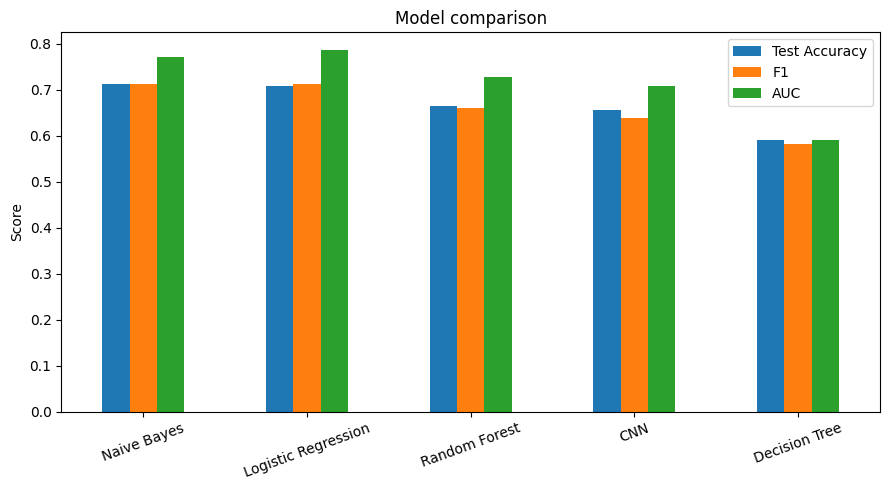

In [23]:
summary[["Test Accuracy", "F1", "AUC"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 9. Discussion
On this synthetic dataset, the CNN's 5-fold CV accuracy is in the same range as the simpler baselines (Logistic Regression and Naive Bayes), rather than decisively outperforming them. This is expected: tabular EHR features here don't have the strong local spatial structure that convolution is designed to exploit, and with a modest number of engineered features, simpler models with fewer parameters tend to generalize at least as well. The CNN remains useful as a comparison point and as an architecture that could scale better if more raw, less hand-engineered features (e.g. time-series vitals) were available.